0. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

0. Import Datasets

In [3]:
dayEvents = pd.read_csv('./dataset/cleaned_dayEvents.csv')
goldPrice = pd.read_csv('./dataset/cleaned_GoldPrice.csv')

In [4]:
dayEvents.head()

,Sl. No,Name of Incident,Day,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome,Date
0,11,PokhranUnknownII Nuclear Tests,1,5,1998,India,Nuclear & WMD,Pokhran,India declared itself a nuclear state,International community,Atal Bihari Vajpayee,Mixed,1998-05-01
1,12,Mumbai Terror Attacks,1,11,2008,India,Terrorism & Violence,Mumbai,Highlighted the threat of international terrorism,Citizens of Mumbai,LashkarUnknowneUnknownTaiba,Negative,2008-11-01
2,18,Operation Blue Star,1,6,1984,India,Military & Conflict,Amritsar,Removal of armed militants from Golden Temple ...,Sikh community,"Indian Government, Sikh militants",Negative,1984-06-01
3,19,Kargil War,1,5,1999,India,Military & Conflict,"Kargil, Ladakh",India regained control of Kargil; heightened p...,Indian Armed Forces,"Indian Government, Pakistani Military",Positive,1999-05-01
4,20,Right to Information Act Enacted,1,6,2005,India,Legal & Legislation,India,Empowered citizens to seek information from pu...,Indian citizens,Government of India,Positive,2005-06-01


In [5]:
goldPrice.head()

,Date,Price(USD),Price(THB)
0,1979-01-01,233.7,4511.3
1,1979-02-01,251.3,4985.7
2,1979-03-01,240.1,4812.9
3,1979-04-01,245.3,4891.0
4,1979-05-01,274.6,5560.8


In [6]:
dayEvents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389 entries, 0 to 388
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Sl. No                              389 non-null    int64 
 1   Name of Incident                    389 non-null    object
 2   Day                                 389 non-null    int64 
 3   Month                               389 non-null    int64 
 4   Year                                389 non-null    int64 
 5   Country                             389 non-null    object
 6   Type of Event                       389 non-null    object
 7   Place Name                          389 non-null    object
 8   Impact                              389 non-null    object
 9   Affected Population                 389 non-null    object
 10  Important Person/Group Responsible  389 non-null    object
 11  Outcome                             389 non-null    object

In [7]:
dayEvents['Date'] = pd.to_datetime(dayEvents['Date'])
goldPrice['Date'] = pd.to_datetime(goldPrice['Date'])

In [8]:
dayEvents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389 entries, 0 to 388
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Sl. No                              389 non-null    int64         
 1   Name of Incident                    389 non-null    object        
 2   Day                                 389 non-null    int64         
 3   Month                               389 non-null    int64         
 4   Year                                389 non-null    int64         
 5   Country                             389 non-null    object        
 6   Type of Event                       389 non-null    object        
 7   Place Name                          389 non-null    object        
 8   Impact                              389 non-null    object        
 9   Affected Population                 389 non-null    object        
 10  Important Person/Group Res

Plot graph

In [9]:
dayEvents['Type of Event'].unique()

array(['Nuclear & WMD', 'Terrorism & Violence', 'Military & Conflict',
       'Legal & Legislation', 'Cultural & Religious', 'Economic',
       'Accident & Industrial Disaster', 'Political', 'Education',
       'Health & Pandemic', 'Sports', 'Natural Disaster',
       'Science & Technology', 'Environmental',
       'Diplomacy & International Relations', 'Social & Civil Rights'],
      dtype=object)

In [10]:
dayEvents['Type of Event'].value_counts()

Type of Event
Political                              103
Diplomacy & International Relations     45
Legal & Legislation                     40
Economic                                37
Military & Conflict                     31
Terrorism & Violence                    21
Social & Civil Rights                   21
Accident & Industrial Disaster          20
Sports                                  17
Natural Disaster                        16
Science & Technology                    10
Cultural & Religious                     9
Health & Pandemic                        8
Environmental                            5
Nuclear & WMD                            4
Education                                2
Name: count, dtype: int64

In [11]:
data = dayEvents[dayEvents['Type of Event'] == 'Political']

In [12]:
merged_df = pd.merge(data, goldPrice, on='Date', how='left')

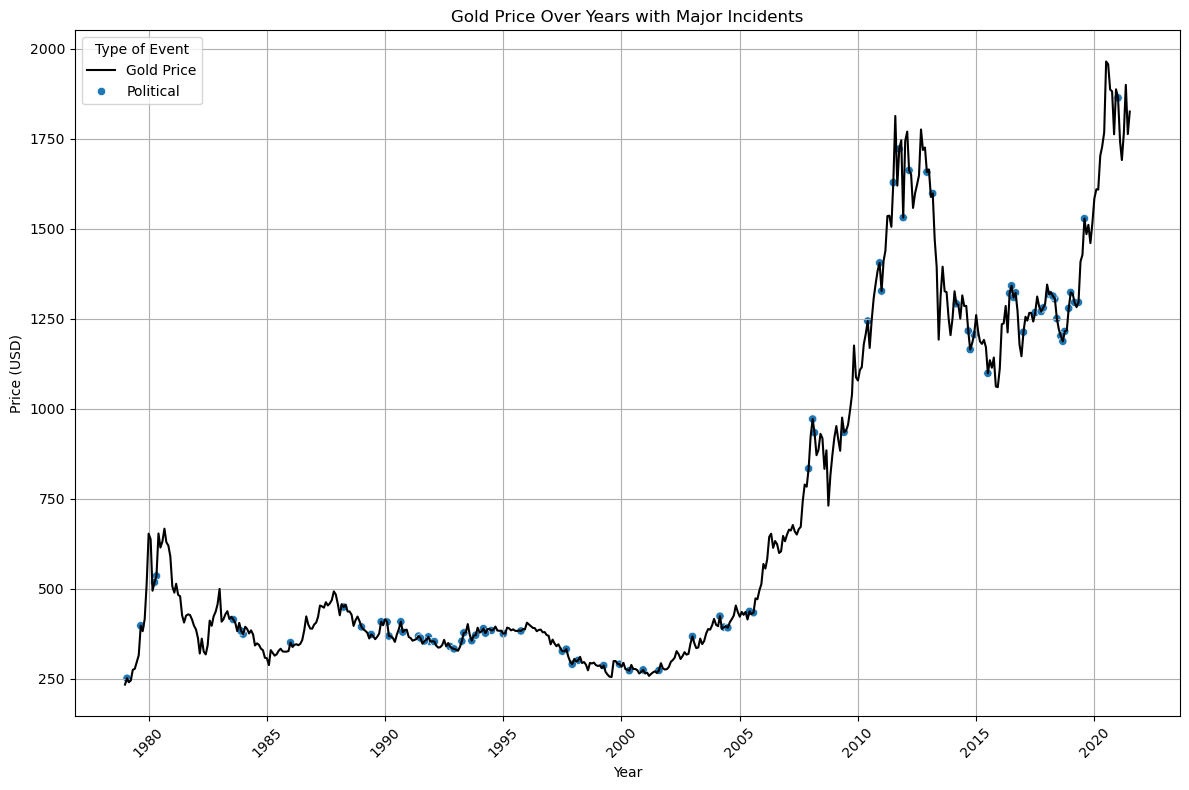

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

plt.figure(figsize=(12,8))

# เส้นราคาทอง
plt.plot(pd.to_datetime(goldPrice['Date']), goldPrice['Price(USD)'], label="Gold Price", color='black')

# จุดเหตุการณ์
sns.scatterplot(
    data=merged_df,
    x='Date',
    y='Price(USD)',
    hue='Type of Event',
)

# ใส่ชื่อเหตุการณ์
# for i, row in merged_df.iterrows():
#     plt.text(
#         row['Date'],
#         row['Price(USD)'] + 20,  # ยกขึ้นเล็กน้อย
#         row['Name of Incident'],
#         fontsize=8,
#         rotation=45
#     )

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)

plt.title("Gold Price Over Years with Major Incidents")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
dayEvents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389 entries, 0 to 388
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Sl. No                              389 non-null    int64         
 1   Name of Incident                    389 non-null    object        
 2   Day                                 389 non-null    int64         
 3   Month                               389 non-null    int64         
 4   Year                                389 non-null    int64         
 5   Country                             389 non-null    object        
 6   Type of Event                       389 non-null    object        
 7   Place Name                          389 non-null    object        
 8   Impact                              389 non-null    object        
 9   Affected Population                 389 non-null    object        
 10  Important Person/Group Res

In [15]:
goldPrice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        511 non-null    datetime64[ns]
 1   Price(USD)  511 non-null    float64       
 2   Price(THB)  511 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 12.1 KB
